<a href="https://colab.research.google.com/github/Amberbops/Notebooks-MP/blob/main/Roblox_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install rapidfuzz
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from rapidfuzz import process
import random
import warnings
warnings.filterwarnings('ignore')

In [4]:
ds = pd.read_csv('/content/roblox_games_data.csv')
ds

,Title,Creator,AgeRecommendation,Active,Favorites,Visits,VoiceChat,Camera,Created,Updated,ServerSize,Genre,Likes,Dislikes,GameLink,DateFetched
0,Catalog Avatar Creator,@ItsMuneeeb,All Ages,19469,3438844,2.8B+,Supported,Supported,7/4/2021,11/5/2024,24,Shopping,1M+,124K+,https://www.roblox.com/games/7041939546/Catalo...,11/5/2024 20:24
1,[HALLOWEEN 🎃] The Mimic,CTStudio,Ages 13+,2709,2911356,988.3M+,Supported,Not Supported,1/15/2021,11/5/2024,45,Survival,982K+,107K+,https://www.roblox.com/games/6243699076/HALLOW...,11/5/2024 20:25
2,[RANKED + MORE] Frisbee Frenzy,johnny cage fan group,All Ages,148,21024,1.5M+,Supported,Not Supported,10/26/2023,11/5/2024,8,NaN,5265,1011,https://www.roblox.com/games/15170454486/RANKE...,11/5/2024 20:25
3,PIGGY: MiniToon Edition [EPISODE 2!],@TaintedMod,All Ages,0,4,44,Not Supported,Not Supported,5/31/2024,7/21/2024,6,NaN,3,0,https://www.roblox.com/games/17681545435/PIGGY...,11/5/2024 20:25
4,Sol's RNG [Era 9],sol's studio,All Ages,22155,635262,765.9M+,Supported,Not Supported,12/3/2023,11/4/2024,20,Simulation,746K+,101K+,https://www.roblox.com/games/15532962292/Sols-...,11/5/2024 20:25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9729,Yeet A Friend!,Low Effort Studios.,All Ages,2423,998236,350.9M+,Not Supported,Not Supported,12/1/2022,11/12/2024,12,Simulation,639K+,34K+,https://www.roblox.com/games/11708967881/Yeet-...,11/13/2024 9:56
9730,Yoinkz! [2-Player],Worried Productions (ROBLOX),All Ages,301,63555,1.6M+,Not Supported,Not Supported,9/28/2024,10/28/2024,30,NaN,4044,601,https://www.roblox.com/games/113787730754402/Y...,11/13/2024 9:56
9731,ZO SAMURAI SWORD FIGHTING,ZO by Voldex,Ages 9+,1283,1572897,548.8M+,Not Supported,Not Supported,4/14/2021,11/7/2024,25,Action,684K+,146K+,https://www.roblox.com/games/6678877691/ZO-SAM...,11/13/2024 9:56
9732,Zombie Attack,Zombie Attack Official,Ages 9+,1072,5771457,1.6B+,Not Supported,Not Supported,12/12/2017,10/14/2024,8,Survival,1M+,79K+,https://www.roblox.com/games/1240123653/Zombie...,11/13/2024 9:56


In [5]:
ds.drop_duplicates(inplace=True)
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9734 entries, 0 to 9733
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Title              9734 non-null   object
 1   Creator            9734 non-null   object
 2   AgeRecommendation  9734 non-null   object
 3   Active             9734 non-null   int64 
 4   Favorites          9734 non-null   int64 
 5   Visits             9734 non-null   object
 6   VoiceChat          9734 non-null   object
 7   Camera             9734 non-null   object
 8   Created            9734 non-null   object
 9   Updated            9734 non-null   object
 10  ServerSize         9734 non-null   int64 
 11  Genre              6914 non-null   object
 12  Likes              9734 non-null   object
 13  Dislikes           9734 non-null   object
 14  GameLink           9734 non-null   object
 15  DateFetched        9734 non-null   object
dtypes: int64(3), object(13)
memory usage: 1.2+

In [6]:
if ds.isna().any().any():
    ds.dropna(inplace=True)
ds.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6914 entries, 0 to 9733
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Title              6914 non-null   object
 1   Creator            6914 non-null   object
 2   AgeRecommendation  6914 non-null   object
 3   Active             6914 non-null   int64 
 4   Favorites          6914 non-null   int64 
 5   Visits             6914 non-null   object
 6   VoiceChat          6914 non-null   object
 7   Camera             6914 non-null   object
 8   Created            6914 non-null   object
 9   Updated            6914 non-null   object
 10  ServerSize         6914 non-null   int64 
 11  Genre              6914 non-null   object
 12  Likes              6914 non-null   object
 13  Dislikes           6914 non-null   object
 14  GameLink           6914 non-null   object
 15  DateFetched        6914 non-null   object
dtypes: int64(3), object(13)
memory usage: 918.3+ KB

In [7]:
ds

,Title,Creator,AgeRecommendation,Active,Favorites,Visits,VoiceChat,Camera,Created,Updated,ServerSize,Genre,Likes,Dislikes,GameLink,DateFetched
0,Catalog Avatar Creator,@ItsMuneeeb,All Ages,19469,3438844,2.8B+,Supported,Supported,7/4/2021,11/5/2024,24,Shopping,1M+,124K+,https://www.roblox.com/games/7041939546/Catalo...,11/5/2024 20:24
1,[HALLOWEEN 🎃] The Mimic,CTStudio,Ages 13+,2709,2911356,988.3M+,Supported,Not Supported,1/15/2021,11/5/2024,45,Survival,982K+,107K+,https://www.roblox.com/games/6243699076/HALLOW...,11/5/2024 20:25
4,Sol's RNG [Era 9],sol's studio,All Ages,22155,635262,765.9M+,Supported,Not Supported,12/3/2023,11/4/2024,20,Simulation,746K+,101K+,https://www.roblox.com/games/15532962292/Sols-...,11/5/2024 20:25
6,🎃Basketball Legends🎃,InfinitySports,All Ages,3445,358703,355.7M+,Supported,Not Supported,7/31/2023,11/5/2024,10,Sports & Racing,241K+,52K+,https://www.roblox.com/games/14259168147/Baske...,11/5/2024 20:25
7,[⏰UPDATE] Slap Battles👏,Slap Battles,Ages 9+,9035,2363252,2.4B+,Supported,Supported,2/17/2021,11/2/2024,16,Action,1M+,245K+,https://www.roblox.com/games/6403373529/UPDATE...,11/5/2024 20:25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9728,WWE 2K23 Roblox Wrestling,Vision Ent.,Ages 9+,278,76396,41.2M+,Not Supported,Not Supported,10/29/2019,10/17/2024,16,Sports & Racing,27K+,6524,https://www.roblox.com/games/4240267866/WWE-2K...,11/13/2024 9:56
9729,Yeet A Friend!,Low Effort Studios.,All Ages,2423,998236,350.9M+,Not Supported,Not Supported,12/1/2022,11/12/2024,12,Simulation,639K+,34K+,https://www.roblox.com/games/11708967881/Yeet-...,11/13/2024 9:56
9731,ZO SAMURAI SWORD FIGHTING,ZO by Voldex,Ages 9+,1283,1572897,548.8M+,Not Supported,Not Supported,4/14/2021,11/7/2024,25,Action,684K+,146K+,https://www.roblox.com/games/6678877691/ZO-SAM...,11/13/2024 9:56
9732,Zombie Attack,Zombie Attack Official,Ages 9+,1072,5771457,1.6B+,Not Supported,Not Supported,12/12/2017,10/14/2024,8,Survival,1M+,79K+,https://www.roblox.com/games/1240123653/Zombie...,11/13/2024 9:56


In [8]:
ds.drop(['AgeRecommendation', 'Camera', 'Created', 'Updated', 'ServerSize', 'DateFetched'], axis=1, inplace=True)

In [9]:
ds

,Title,Creator,Active,Favorites,Visits,VoiceChat,Genre,Likes,Dislikes,GameLink
0,Catalog Avatar Creator,@ItsMuneeeb,19469,3438844,2.8B+,Supported,Shopping,1M+,124K+,https://www.roblox.com/games/7041939546/Catalo...
1,[HALLOWEEN 🎃] The Mimic,CTStudio,2709,2911356,988.3M+,Supported,Survival,982K+,107K+,https://www.roblox.com/games/6243699076/HALLOW...
4,Sol's RNG [Era 9],sol's studio,22155,635262,765.9M+,Supported,Simulation,746K+,101K+,https://www.roblox.com/games/15532962292/Sols-...
6,🎃Basketball Legends🎃,InfinitySports,3445,358703,355.7M+,Supported,Sports & Racing,241K+,52K+,https://www.roblox.com/games/14259168147/Baske...
7,[⏰UPDATE] Slap Battles👏,Slap Battles,9035,2363252,2.4B+,Supported,Action,1M+,245K+,https://www.roblox.com/games/6403373529/UPDATE...
...,...,...,...,...,...,...,...,...,...,...
9728,WWE 2K23 Roblox Wrestling,Vision Ent.,278,76396,41.2M+,Not Supported,Sports & Racing,27K+,6524,https://www.roblox.com/games/4240267866/WWE-2K...
9729,Yeet A Friend!,Low Effort Studios.,2423,998236,350.9M+,Not Supported,Simulation,639K+,34K+,https://www.roblox.com/games/11708967881/Yeet-...
9731,ZO SAMURAI SWORD FIGHTING,ZO by Voldex,1283,1572897,548.8M+,Not Supported,Action,684K+,146K+,https://www.roblox.com/games/6678877691/ZO-SAM...
9732,Zombie Attack,Zombie Attack Official,1072,5771457,1.6B+,Not Supported,Survival,1M+,79K+,https://www.roblox.com/games/1240123653/Zombie...


In [10]:
ds.nunique()

,0
Title,1045
Creator,822
Active,3356
Favorites,6833
Visits,2789
VoiceChat,2
Genre,16
Likes,1484
Dislikes,2672
GameLink,1671


In [11]:
ds.Title.value_counts()

,count
Title,
Shindo Life [239],12
LewisLife 🏡 RP [Free UGC],8
Like or Pass,8
Logo Block Race,8
Logo Race!,8
...,...
[Trinity] Console VS Coffin,1
[Building Tool] Teardown the bridge Destruction,1
Cursed Arena,1


In [12]:
ds.drop_duplicates(subset=['Title', 'GameLink'], inplace=True)

In [13]:
ds.dropna()

,Title,Creator,Active,Favorites,Visits,VoiceChat,Genre,Likes,Dislikes,GameLink
0,Catalog Avatar Creator,@ItsMuneeeb,19469,3438844,2.8B+,Supported,Shopping,1M+,124K+,https://www.roblox.com/games/7041939546/Catalo...
1,[HALLOWEEN 🎃] The Mimic,CTStudio,2709,2911356,988.3M+,Supported,Survival,982K+,107K+,https://www.roblox.com/games/6243699076/HALLOW...
4,Sol's RNG [Era 9],sol's studio,22155,635262,765.9M+,Supported,Simulation,746K+,101K+,https://www.roblox.com/games/15532962292/Sols-...
6,🎃Basketball Legends🎃,InfinitySports,3445,358703,355.7M+,Supported,Sports & Racing,241K+,52K+,https://www.roblox.com/games/14259168147/Baske...
7,[⏰UPDATE] Slap Battles👏,Slap Battles,9035,2363252,2.4B+,Supported,Action,1M+,245K+,https://www.roblox.com/games/6403373529/UPDATE...
...,...,...,...,...,...,...,...,...,...,...
9202,[Trinity] Console VS Coffin,Pixel Painter,951,1057556,58.1M+,Not Supported,Simulation,9599,2379,https://www.roblox.com/games/15804157233/Toile...
9218,[Building Tool] Teardown the bridge Destruction,@gabrieltag465255,299,1965511,28.8M+,Not Supported,Simulation,28K+,5160,https://www.roblox.com/games/12123018231/Hamme...
9219,Cursed Arena,MiraiExp,578,271517,153.2M+,Not Supported,Action,160K+,39K+,https://www.roblox.com/games/14206387098/Hanam...
9439,UGC Steal Points,UnderGame Studios,803,19438,14.4M+,Not Supported,Action,26K+,4522,https://www.roblox.com/games/15998144390/UGC-S...


In [14]:
ds.reset_index(drop=True, inplace=True)
ds

,Title,Creator,Active,Favorites,Visits,VoiceChat,Genre,Likes,Dislikes,GameLink
0,Catalog Avatar Creator,@ItsMuneeeb,19469,3438844,2.8B+,Supported,Shopping,1M+,124K+,https://www.roblox.com/games/7041939546/Catalo...
1,[HALLOWEEN 🎃] The Mimic,CTStudio,2709,2911356,988.3M+,Supported,Survival,982K+,107K+,https://www.roblox.com/games/6243699076/HALLOW...
2,Sol's RNG [Era 9],sol's studio,22155,635262,765.9M+,Supported,Simulation,746K+,101K+,https://www.roblox.com/games/15532962292/Sols-...
3,🎃Basketball Legends🎃,InfinitySports,3445,358703,355.7M+,Supported,Sports & Racing,241K+,52K+,https://www.roblox.com/games/14259168147/Baske...
4,[⏰UPDATE] Slap Battles👏,Slap Battles,9035,2363252,2.4B+,Supported,Action,1M+,245K+,https://www.roblox.com/games/6403373529/UPDATE...
...,...,...,...,...,...,...,...,...,...,...
1811,[Trinity] Console VS Coffin,Pixel Painter,951,1057556,58.1M+,Not Supported,Simulation,9599,2379,https://www.roblox.com/games/15804157233/Toile...
1812,[Building Tool] Teardown the bridge Destruction,@gabrieltag465255,299,1965511,28.8M+,Not Supported,Simulation,28K+,5160,https://www.roblox.com/games/12123018231/Hamme...
1813,Cursed Arena,MiraiExp,578,271517,153.2M+,Not Supported,Action,160K+,39K+,https://www.roblox.com/games/14206387098/Hanam...
1814,UGC Steal Points,UnderGame Studios,803,19438,14.4M+,Not Supported,Action,26K+,4522,https://www.roblox.com/games/15998144390/UGC-S...


## 🔢 Convert String Numbers to Numeric

In [15]:
def convert_x_to_numeric(x_str):
    if isinstance(x_str, (int, float)):
        return x_str
    x_str = str(x_str).replace(',', '').replace('+', '')
    if 'B' in x_str:
        return float(x_str.replace('B', '')) * 1_000_000_000
    elif 'M' in x_str:
        return float(x_str.replace('M', '')) * 1_000_000
    elif 'K' in x_str:
        return float(x_str.replace('K', '')) * 1_000
    else:
        return float(x_str)

ds['Visits'] = ds['Visits'].apply(convert_x_to_numeric)
ds['Favorites'] = ds['Favorites'].apply(convert_x_to_numeric)
ds['Likes'] = ds['Likes'].apply(convert_x_to_numeric)
ds['Dislikes'] = ds['Dislikes'].apply(convert_x_to_numeric)

In [16]:
print('DataFrame after converting Visits to numeric:')
display(ds.head())
ds.info()

DataFrame after converting Visits to numeric:


,Title,Creator,Active,Favorites,Visits,VoiceChat,Genre,Likes,Dislikes,GameLink
0,Catalog Avatar Creator,@ItsMuneeeb,19469,3438844,2.800000e+09,Supported,Shopping,1000000.0,124000.0,https://www.roblox.com/games/7041939546/Catalo...
1,[HALLOWEEN 🎃] The Mimic,CTStudio,2709,2911356,9.883000e+08,Supported,Survival,982000.0,107000.0,https://www.roblox.com/games/6243699076/HALLOW...
2,Sol's RNG [Era 9],sol's studio,22155,635262,7.659000e+08,Supported,Simulation,746000.0,101000.0,https://www.roblox.com/games/15532962292/Sols-...
3,🎃Basketball Legends🎃,InfinitySports,3445,358703,3.557000e+08,Supported,Sports & Racing,241000.0,52000.0,https://www.roblox.com/games/14259168147/Baske...
4,[⏰UPDATE] Slap Battles👏,Slap Battles,9035,2363252,2.400000e+09,Supported,Action,1000000.0,245000.0,https://www.roblox.com/games/6403373529/UPDATE...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1816 entries, 0 to 1815
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Title      1816 non-null   object 
 1   Creator    1816 non-null   object 
 2   Active     1816 non-null   int64  
 3   Favorites  1816 non-null   int64  
 4   Visits     1816 non-null   float64
 5   VoiceChat  1816 non-null   object 
 6   Genre      1816 non-null   object 
 7   Likes      1816 non-null   float64
 8   Dislikes   1816 non-null   float64
 9   GameLink   1816 non-null   object 
dtypes: float64(3), int64(2), object(5)
memory usage: 142.0+ KB


In [17]:
ds['VoiceChat'] == "Supported"

,VoiceChat
0,True
1,True
2,True
3,True
4,True
...,...
1811,False
1812,False
1813,False
1814,False


## 🎙️ VoiceChat Encoding

In [18]:
def vc_filter(voice_chat_status):
    if voice_chat_status == "Supported":
        return 1
    else:
        return 0

In [19]:
ds['VoiceChat_Numeric'] = ds['VoiceChat'].apply(vc_filter)

print(f"Number of games with Supported VoiceChat: {ds['VoiceChat_Numeric'].sum()}")
print(f"First 5 rows of the new 'VoiceChat_Numeric' column:")
display(ds[['VoiceChat', 'VoiceChat_Numeric']].head())

Number of games with Supported VoiceChat: 1038
First 5 rows of the new 'VoiceChat_Numeric' column:


,VoiceChat,VoiceChat_Numeric
0,Supported,1
1,Supported,1
2,Supported,1
3,Supported,1
4,Supported,1


## 🔍 Filter Function

In [20]:
def filter(df_to_filter, col_name, filter_limit=None, voice_chat_status=None):
    filtered_df = df_to_filter.copy()
    if voice_chat_status is not None:
        filtered_df = filtered_df[filtered_df['VoiceChat'] == voice_chat_status]
    if filter_limit is None:
        return filtered_df[filtered_df[col_name] > 0]
    else:
        return filtered_df[filtered_df[col_name] >= filter_limit]

In [21]:
filtered_ds = filter(ds, 'Active', 1000, voice_chat_status="Supported")
print(f"Number of rows before filtering: {len(ds)}")
display(filtered_ds.head())
print(f"Number of rows after filtering: {len(filtered_ds)}")

Number of rows before filtering: 1816


,Title,Creator,Active,Favorites,Visits,VoiceChat,Genre,Likes,Dislikes,GameLink,VoiceChat_Numeric
0,Catalog Avatar Creator,@ItsMuneeeb,19469,3438844,2.800000e+09,Supported,Shopping,1000000.0,124000.0,https://www.roblox.com/games/7041939546/Catalo...,1
1,[HALLOWEEN 🎃] The Mimic,CTStudio,2709,2911356,9.883000e+08,Supported,Survival,982000.0,107000.0,https://www.roblox.com/games/6243699076/HALLOW...,1
2,Sol's RNG [Era 9],sol's studio,22155,635262,7.659000e+08,Supported,Simulation,746000.0,101000.0,https://www.roblox.com/games/15532962292/Sols-...,1
3,🎃Basketball Legends🎃,InfinitySports,3445,358703,3.557000e+08,Supported,Sports & Racing,241000.0,52000.0,https://www.roblox.com/games/14259168147/Baske...,1
4,[⏰UPDATE] Slap Battles👏,Slap Battles,9035,2363252,2.400000e+09,Supported,Action,1000000.0,245000.0,https://www.roblox.com/games/6403373529/UPDATE...,1


Number of rows after filtering: 496


## 🔗 Game Link DataFrame

In [22]:
link_df = ds[['Title', 'GameLink']]
link_df.reset_index(drop=True, inplace=True)
link_df

,Title,GameLink
0,Catalog Avatar Creator,https://www.roblox.com/games/7041939546/Catalo...
1,[HALLOWEEN 🎃] The Mimic,https://www.roblox.com/games/6243699076/HALLOW...
2,Sol's RNG [Era 9],https://www.roblox.com/games/15532962292/Sols-...
3,🎃Basketball Legends🎃,https://www.roblox.com/games/14259168147/Baske...
4,[⏰UPDATE] Slap Battles👏,https://www.roblox.com/games/6403373529/UPDATE...
...,...,...
1811,[Trinity] Console VS Coffin,https://www.roblox.com/games/15804157233/Toile...
1812,[Building Tool] Teardown the bridge Destruction,https://www.roblox.com/games/12123018231/Hamme...
1813,Cursed Arena,https://www.roblox.com/games/14206387098/Hanam...
1814,UGC Steal Points,https://www.roblox.com/games/15998144390/UGC-S...


## 🔎 Smart Search with RapidFuzz

In [23]:
def smart_search(query, df, limit=10, threshold=70):
    """
    Search Roblox game titles in a DataFrame with robust handling:
    - Case-insensitive exact match first
    - Partial substring match fallback
    - Fuzzy matching for typos as final fallback

    Parameters:
        query (str): User input string
        df (pd.DataFrame): DataFrame with columns ['Title', 'GameLink']
        limit (int): Max fuzzy results to return
        threshold (int): Minimum similarity score (0-100)

    Returns:
        pd.DataFrame or None: Matching titles and links
    """
    query_lower = query.lower()

    # 1. Exact match (case-insensitive)
    exact_match_df = df[df['Title'].str.lower() == query_lower]
    if not exact_match_df.empty:
        return exact_match_df[['Title', 'GameLink']]

    # 2. Substring match (case-insensitive)
    substr_match_df = df[df['Title'].str.lower().str.contains(query_lower, na=False)]
    if not substr_match_df.empty:
        return substr_match_df[['Title', 'GameLink']].head(limit)

    # 3. Fuzzy match for typos
    titles = df['Title'].tolist()
    results = process.extract(query, titles, limit=limit, score_cutoff=threshold)
    if results:
        return df.iloc[[x[2] for x in results]][['Title', 'GameLink']]

    return None

In [24]:
smart_search('obby', link_df)

,Title,GameLink
15,2 Player Monkey Obby,https://www.roblox.com/games/17521736603/2-Pla...
30,[UPGRADE] BARRY'S PRISON RUN! (OBBY),https://www.roblox.com/games/8712817601/UPGRAD...
39,Ez Obby But You Get Kicked If You Die!,https://www.roblox.com/games/8552239983/Ez-Obb...
56,Blush Canyon (For Obby King),https://www.roblox.com/games/3218570640/Blush-...
60,[W50] Obby But You’re On a Bike,https://www.roblox.com/games/14184086618/W50-O...
67,Teamwork Puzzles 2 (Obby),https://www.roblox.com/games/12641272458/Teamw...
74,Become Forklift Certified Obby!,https://www.roblox.com/games/13033713206/Becom...
75,[🔥SABOTAGE] Easy Size Obby,https://www.roblox.com/games/14337656835/SABOT...
103,Team Nursery Escape! (TEAMWORK OBBY),https://www.roblox.com/games/15169554126/Team-...
108,Escape School Obby! (NEW) 🎃,https://www.roblox.com/games/5327491283/Escape...


## 🎵 Playlist Builder

In [25]:
def make_play_list(df):
    """
    Interactive playlist builder for Roblox games.
    Lets user search and add games by fuzzy title search.

    Parameters:
        df (pd.DataFrame): DataFrame with 'Title' and 'GameLink' columns

    Returns:
        pd.DataFrame: Playlist of chosen games with Title and GameLink
    """
    my_list = []

    while True:
        game_title = input("Search for a game to add: ")
        search_results = smart_search(game_title, df)

        if search_results is not None and not search_results.empty:
            # Show results with numbered index for easy picking
            search_results_reset = search_results.reset_index(drop=True)
            print(search_results_reset.to_string())
            option_choose = input(f"Pick a game (0 to {len(search_results_reset)-1}): ")
            try:
                chosen_row = search_results_reset.iloc[int(option_choose)]
                my_list.append({'Title': chosen_row['Title'], 'GameLink': chosen_row['GameLink']})
                print(f"✅ '{chosen_row['Title']}' added to your playlist!\n")
            except (IndexError, ValueError):
                print("❌ Invalid selection. Please enter a valid index.")
        else:
            print("⚠️  No games found for your search. Try a different keyword.")

        add_more = input("Add more games? (y/n): ")
        if add_more.lower() != 'y':
            break

    playlist_df = pd.DataFrame(my_list)
    if not playlist_df.empty:
        print(f"\n🎮 Your Playlist ({len(playlist_df)} games):")
        print(playlist_df.to_string(index=False))
    else:
        print("Your playlist is empty.")
    return playlist_df

In [26]:
# Uncomment to use interactively in Colab
# make_play_list(link_df)

## 🎲 Random Game Picker

In [27]:
ds.Genre.isnull().sum()

np.int64(0)

In [28]:
def randomize_game(df, genre=None, voice_chat_only=False, min_visits=0):
    """
    Pick a random game from the dataset with optional filters.

    Parameters:
        df (pd.DataFrame): The games DataFrame
        genre (str): Filter by genre (case-insensitive). None = any genre.
        voice_chat_only (bool): If True, only include games with VoiceChat supported.
        min_visits (int/float): Minimum number of visits required.

    Returns:
        pd.Series or None: A randomly chosen game row, or None if no match.
    """
    filtered = df.copy()

    if genre:
        filtered = filtered[filtered['Genre'].str.lower() == genre.lower()]

    if voice_chat_only:
        filtered = filtered[filtered['VoiceChat'] == 'Supported']

    if min_visits > 0:
        filtered = filtered[filtered['Visits'] >= min_visits]

    if filtered.empty:
        print("No games found with the given filters.")
        return None

    chosen = filtered.sample(1).iloc[0]
    print(f"\n🎲 Random Game Pick:")
    print(f"  Title     : {chosen['Title']}")
    print(f"  Genre     : {chosen.get('Genre', 'N/A')}")
    print(f"  Visits    : {int(chosen['Visits']):,}")
    print(f"  Likes     : {int(chosen['Likes']):,}")
    print(f"  VoiceChat : {chosen['VoiceChat']}")
    print(f"  Link      : {chosen['GameLink']}")
    return chosen

In [29]:
# Test randomize_game
randomize_game(ds)


🎲 Random Game Pick:
  Title     : Realistic Destruction
  Genre     : Simulation
  Visits    : 3,400,000
  Likes     : 5,235
  VoiceChat : Not Supported
  Link      : https://www.roblox.com/games/6905091496/Realistic-Destruction?gameSearchSessionInfo=98e42b6f-dda9-4689-8d68-08b777504e09&amp;isAd=false&amp;nativeAdData=&amp;numberOfLoadedTiles=40&amp;page=searchPage&amp;placeId=6905091496&amp;position=0&amp;universeId=2637211100


,105
Title,Realistic Destruction
Creator,@Andreolinski
Active,30
Favorites,15827
Visits,3400000.0
VoiceChat,Not Supported
Genre,Simulation
Likes,5235.0
Dislikes,1496.0
GameLink,https://www.roblox.com/games/6905091496/Realis...


In [30]:
# Test with genre filter (adjust genre name to one in your dataset)
randomize_game(ds, voice_chat_only=True, min_visits=1_000_000)


🎲 Random Game Pick:
  Title     : Cooking Simulator
  Genre     : Simulation
  Visits    : 7,900,000
  Likes     : 6,880
  VoiceChat : Supported
  Link      : https://www.roblox.com/games/15157228571/Cooking-Simulator?gameSearchSessionInfo=65dfedd3-44f4-4ec5-bf17-2928999a6786&amp;isAd=false&amp;nativeAdData=&amp;numberOfLoadedTiles=40&amp;page=searchPage&amp;placeId=15157228571&amp;position=0&amp;universeId=5224767567


,1394
Title,Cooking Simulator
Creator,FLOH Game
Active,86
Favorites,29970
Visits,7900000.0
VoiceChat,Supported
Genre,Simulation
Likes,6880.0
Dislikes,1090.0
GameLink,https://www.roblox.com/games/15157228571/Cooki...


## 📊 Data Visualization

In [31]:
# ============================================================
# 📊 DATA VISUALIZATION
# ============================================================

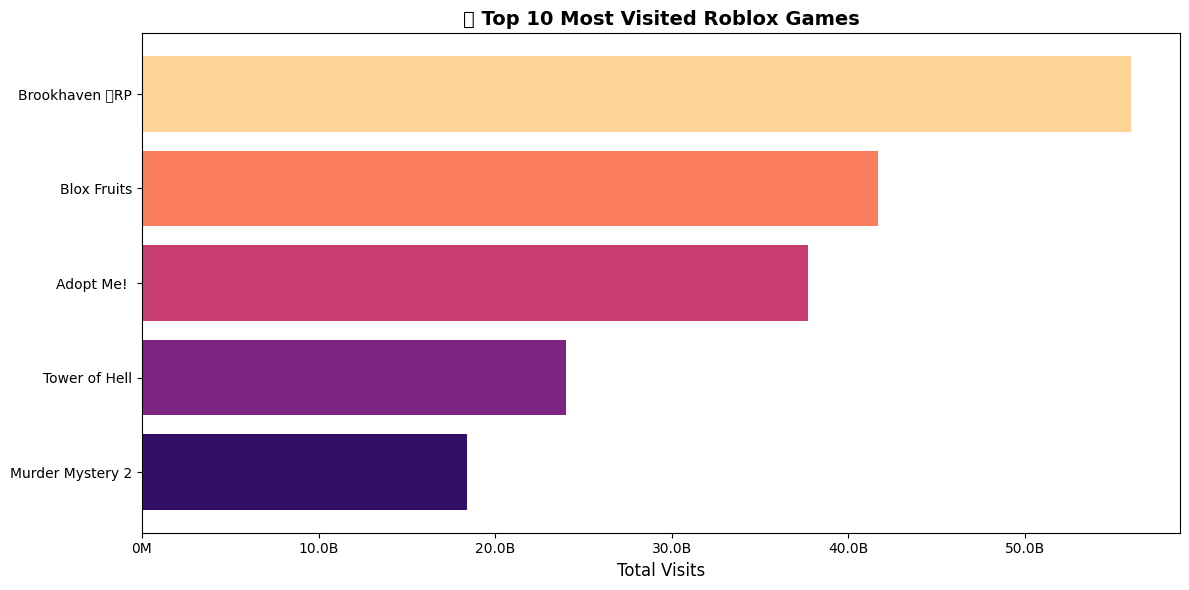

In [32]:
# --- 1. Top 10 Most Visited Games ---
top_visits = ds.nlargest(10, 'Visits')[['Title', 'Visits']].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_visits['Title'][::-1], top_visits['Visits'][::-1],
               color=sns.color_palette("magma", 10))
ax.set_xlabel('Total Visits', fontsize=12)
ax.set_title('🏆 Top 10 Most Visited Roblox Games', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B' if x >= 1e9 else f'{x/1e6:.0f}M'))
plt.tight_layout()
plt.show()

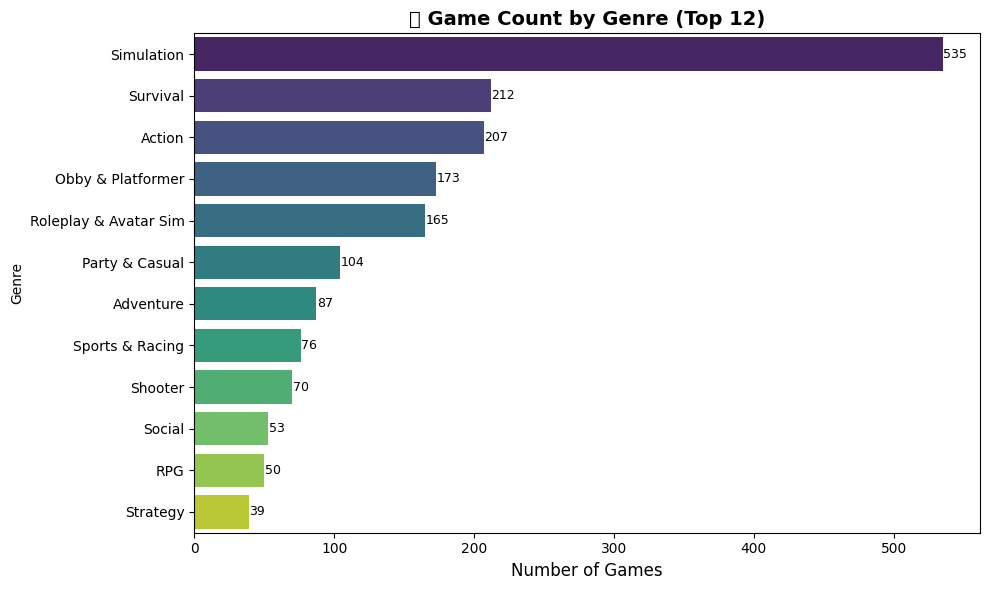

In [33]:
# --- 2. Game Count by Genre ---
genre_counts = ds['Genre'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index,
            palette='viridis', ax=ax)
ax.set_xlabel('Number of Games', fontsize=12)
ax.set_title('🎮 Game Count by Genre (Top 12)', fontsize=14, fontweight='bold')
for i, v in enumerate(genre_counts.values):
    ax.text(v + 0.5, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

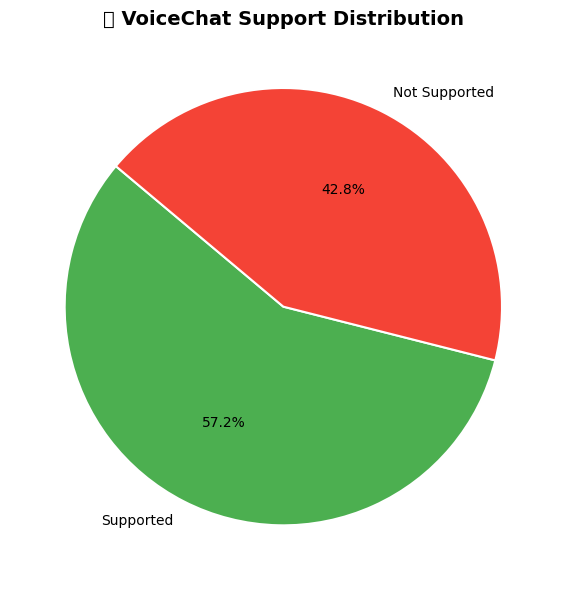

In [34]:
# --- 3. VoiceChat Support Distribution ---
vc_counts = ds['VoiceChat'].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
colors = ['#4CAF50', '#F44336', '#2196F3']
wedges, texts, autotexts = ax.pie(
    vc_counts.values,
    labels=vc_counts.index,
    autopct='%1.1f%%',
    colors=colors[:len(vc_counts)],
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
ax.set_title('🎙️ VoiceChat Support Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

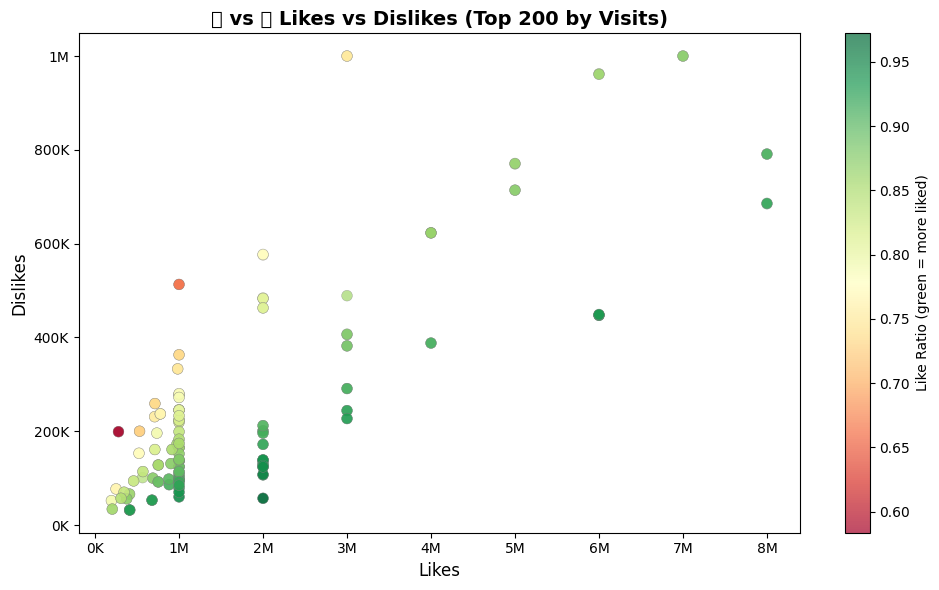

In [35]:
# --- 4. Likes vs Dislikes (Top 200 by Visits) ---
top200 = ds.nlargest(200, 'Visits').copy()
top200['Like_Ratio'] = top200['Likes'] / (top200['Likes'] + top200['Dislikes'] + 1)

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    top200['Likes'], top200['Dislikes'],
    c=top200['Like_Ratio'], cmap='RdYlGn',
    alpha=0.7, s=60, edgecolors='grey', linewidths=0.3
)
plt.colorbar(sc, ax=ax, label='Like Ratio (green = more liked)')
ax.set_xlabel('Likes', fontsize=12)
ax.set_ylabel('Dislikes', fontsize=12)
ax.set_title('👍 vs 👎 Likes vs Dislikes (Top 200 by Visits)', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
plt.tight_layout()
plt.show()

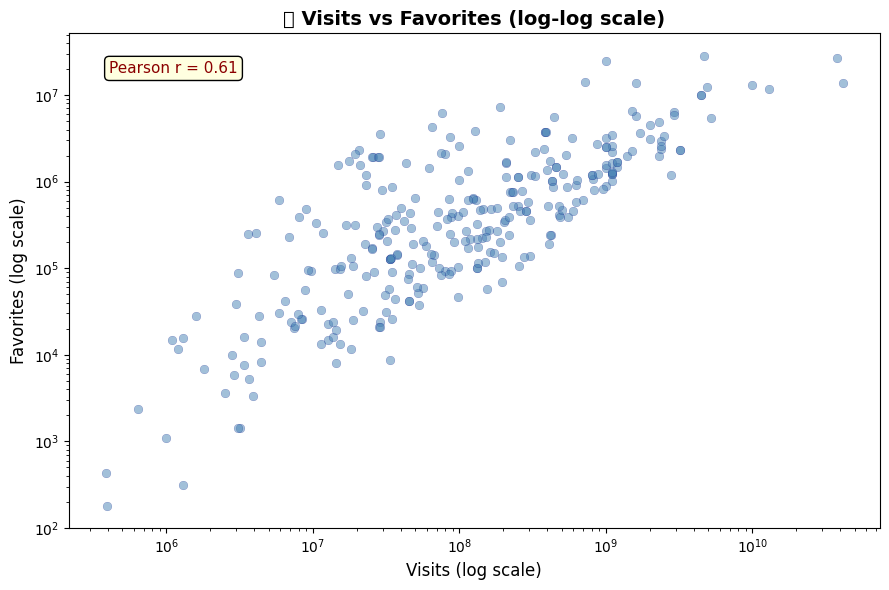

In [36]:
# --- 5. Visits vs Favorites Correlation ---
sample = ds[(ds['Visits'] > 0) & (ds['Favorites'] > 0)].sample(min(300, len(ds)), random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(sample['Visits'], sample['Favorites'],
           alpha=0.5, color='steelblue', edgecolors='navy', linewidths=0.2, s=40)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Visits (log scale)', fontsize=12)
ax.set_ylabel('Favorites (log scale)', fontsize=12)
ax.set_title('⭐ Visits vs Favorites (log-log scale)', fontsize=14, fontweight='bold')
corr = sample[['Visits','Favorites']].corr().iloc[0,1]
ax.text(0.05, 0.92, f'Pearson r = {corr:.2f}', transform=ax.transAxes,
        fontsize=11, color='darkred', bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow'))
plt.tight_layout()
plt.show()

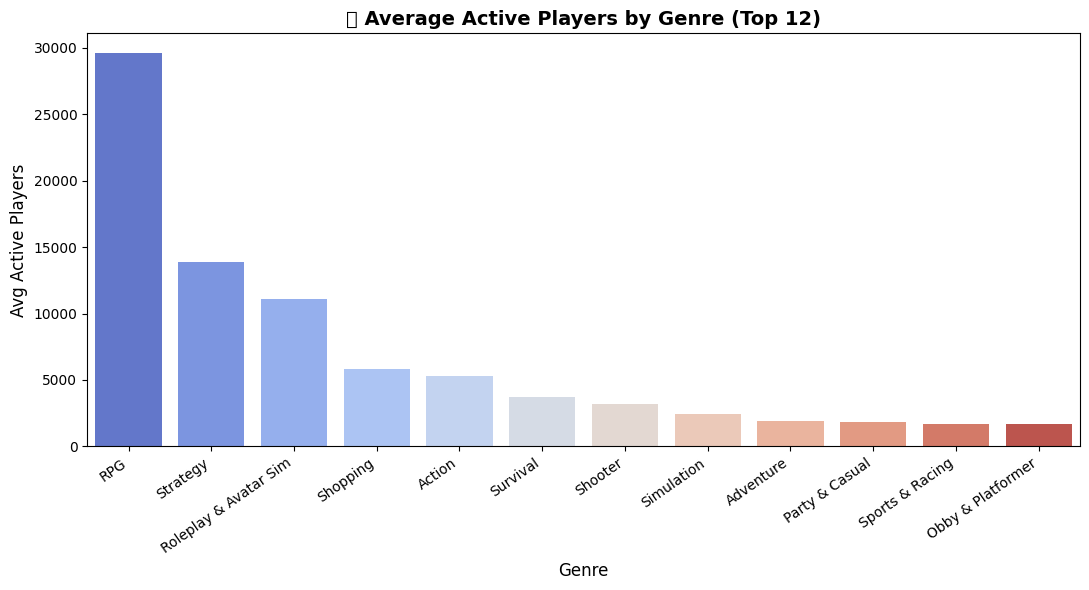

In [37]:
# --- 6. Average Active Players by Genre ---
genre_active = ds.groupby('Genre')['Active'].mean().sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(x=genre_active.index, y=genre_active.values,
            palette='coolwarm', ax=ax)
ax.set_xlabel('Genre', fontsize=12)
ax.set_ylabel('Avg Active Players', fontsize=12)
ax.set_title('🕹️ Average Active Players by Genre (Top 12)', fontsize=14, fontweight='bold')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

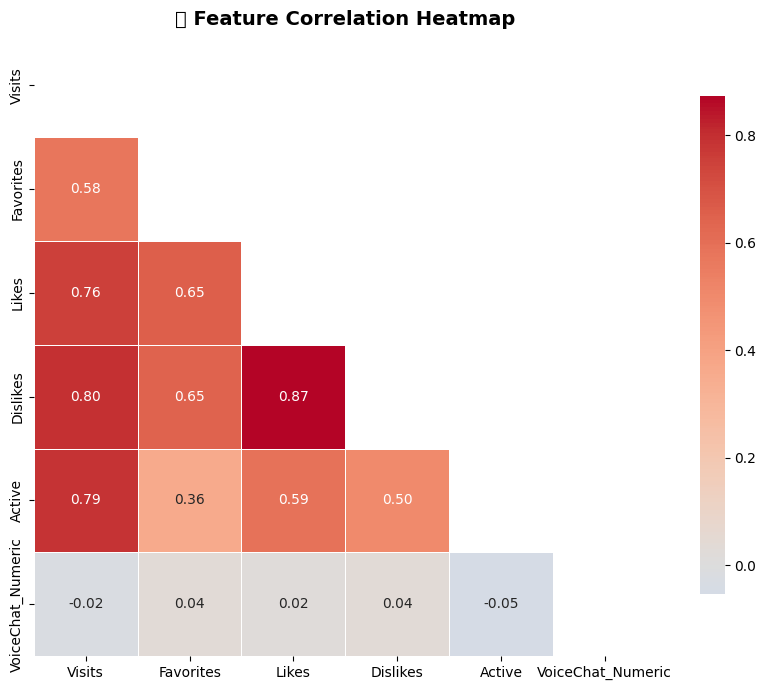

In [39]:
ds
# --- 7. Correlation Heatmap ---
numeric_cols = ['Visits', 'Favorites', 'Likes', 'Dislikes', 'Active', 'VoiceChat_Numeric']
corr_matrix = ds[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            ax=ax, square=True, cbar_kws={'shrink': 0.8})
ax.set_title('🔥 Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()